# Validación de Threshold y Evaluación Externa

## Objetivo
Establecer threshold óptimo mediante validación con 3 planos (ensemble), aplicarlo al test set y evaluar en dataset externo de Croacia.

## Pipeline
1. Carga de modelos CNN ResNet50 Multiseed (3 planos)
2. Predicciones en validación con ensemble de planos
3. Búsqueda de threshold óptimo (recall-maximizing, min precision >= 0.75)
4. Evaluación en test set con threshold calibrado
5. Validación externa en Croacia (sagittal únicamente)
6. Análisis de generalización y domain shift

## 1. Setup e Importaciones

In [1]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import roc_auc_score, roc_curve, auc, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

sys.path.insert(0, '/home/palodo2/acl_classifier')

print("Importaciones exitosas")

/home/palodo2/acl_classifier/.venv/lib/python3.12/site-packages/seaborn/_statistics.py:31: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.6)
  from scipy.stats import gaussian_kde


Importaciones exitosas


## 2. Configuración de Rutas y Constantes

In [2]:
os.chdir('/home/palodo2/acl_classifier/models/cnn')

BASE_DIR = Path('/home/palodo2/acl_classifier')
CHECKPOINTS_DIR = BASE_DIR / 'checkpoints'
DATA_DIR = BASE_DIR / 'data'
RESULTS_DIR = BASE_DIR / 'models' / 'cnn' / 'results_threshold'
RESULTS_DIR.mkdir(exist_ok=True, parents=True)

# Modelos CNN ResNet50 Multiseed
CNN_MULTISEED_DIR = CHECKPOINTS_DIR / 'cnn_multiseed_resnet50'
CNN_MODELS = {
    'sagittal': CNN_MULTISEED_DIR / 'best_sagittal_multiseed_final.pth',
    'coronal': CNN_MULTISEED_DIR / 'best_coronal_multiseed_final.pth',
    'axial': CNN_MULTISEED_DIR / 'best_axial_multiseed_final.pth'
}

# Rutas de datos
VAL_CSV = DATA_DIR / 'val-acl.csv'
TEST_CSV = DATA_DIR / 'test-acl.csv'
CROATIA_DIR = DATA_DIR / 'croatia_npy_volumes_full'
CROATIA_METADATA_CSV = CROATIA_DIR / 'metadata_final.csv'
CROATIA_INDICES_CACHE = DATA_DIR / 'slice_indices_final' / 'croatia_sagittal_indices_full.json'
CROATIA_CNN_SELECTOR_PATH = CHECKPOINTS_DIR / 'acl_slice_classifier_v3' / 'best_model_f1.pth'
CROATIA_SAGITTAL_K = 5
CROATIA_REGENERATE_INDICES = True

# GPU
def get_safe_device():
    if not torch.cuda.is_available():
        return torch.device('cpu')

    try:
        supported_arches = set(torch.cuda.get_arch_list())
        major, minor = torch.cuda.get_device_capability(0)
        device_arch = f'sm_{major}{minor}'
        if device_arch not in supported_arches:
            print(f'  GPU detectada ({device_arch}) pero el build de PyTorch no la soporta. Usando CPU.')
            return torch.device('cpu')
    except Exception as exc:
        print(f'  No se pudo validar compatibilidad CUDA: {exc}. Usando CPU.')
        return torch.device('cpu')

    return torch.device('cuda')

DEVICE = get_safe_device()

PLANES = ['sagittal', 'coronal', 'axial']
ENSEMBLE_WEIGHTS = {'sagittal': 1/3, 'coronal': 1/3, 'axial': 1/3}

print(f"Dispositivo: {DEVICE}")
print(f"Directorio resultados: {RESULTS_DIR}")

Dispositivo: cuda
Directorio resultados: /home/palodo2/acl_classifier/models/cnn/results_threshold


## 3. Importar Módulos

In [3]:
from src.data_loader import OptimizedMRNetDataset, get_val_test_transform
from src.models import SimpleCNNSelector, CNNMultiSliceClassifier

print("Módulos importados")

Módulos importados


## 4. Funciones Auxiliares

In [4]:
def get_predictions_on_dataset(model, dataloader, device):
    """Obtener predicciones y etiquetas de un dataloader"""
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            if isinstance(batch, (list, tuple)):
                if len(batch) == 3:
                    images, labels, case_ids = batch
                elif len(batch) == 2:
                    images, labels = batch
                else:
                    images = batch[0]
                    labels = batch[1] if len(batch) > 1 else None
            else:
                images = batch
                labels = None

            images = images.to(device)
            outputs = model(images)

            if isinstance(outputs, tuple):
                logits = outputs[0]
            else:
                logits = outputs

            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.extend(probs.flatten())
            if labels is not None:
                all_labels.extend(labels.cpu().numpy() if hasattr(labels, 'cpu') else labels)

    return np.array(all_probs), np.array(all_labels)

def ensemble_predictions_weighted(preds_dict, weights):
    """Combinar predicciones de múltiples planos con pesos"""
    ensemble = np.zeros_like(preds_dict[list(preds_dict.keys())[0]])
    for plane, preds in preds_dict.items():
        ensemble += weights[plane] * preds
    return ensemble

def calculate_metrics(labels, probs, threshold=0.5):
    """Calcular métricas en threshold dado"""
    predictions = (probs >= threshold).astype(int)

    tn = ((predictions == 0) & (labels == 0)).sum()
    tp = ((predictions == 1) & (labels == 1)).sum()
    fn = ((predictions == 0) & (labels == 1)).sum()
    fp = ((predictions == 1) & (labels == 0)).sum()

    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    auc_score = roc_auc_score(labels, probs)

    return {
        'auc': auc_score,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'specificity': specificity,
        'f1': f1,
        'tp': tp,
        'tn': tn,
        'fp': fp,
        'fn': fn
    }

def find_optimal_threshold_recall(labels, probs, min_precision=0.70):
    """Encontrar threshold que maximiza recall manteniendo precision mínima"""
    thresholds = np.linspace(0, 1, 1000)
    best_threshold = 0.5
    best_metrics = None
    all_metrics = []

    for thresh in thresholds:
        metrics = calculate_metrics(labels, probs, threshold=thresh)
        all_metrics.append({'threshold': thresh, **metrics})

        if metrics['precision'] >= min_precision:
            if best_metrics is None or metrics['recall'] > best_metrics['recall']:
                best_metrics = metrics
                best_threshold = thresh

    return best_threshold, best_metrics, all_metrics

def load_volume_normalized(volume_path):
    """Carga un volumen .npy y lo normaliza con min-max."""
    volume = np.load(volume_path).astype(np.float32)
    volume_min = volume.min()
    volume_max = volume.max()
    if volume_max > volume_min:
        volume = (volume - volume_min) / (volume_max - volume_min)
    return volume

def build_croatia_sagittal_indices(df, data_dir, selector_checkpoint, output_path, k=5, force=False, device=DEVICE):
    """Genera índices sagitales para Croacia usando el CNN selector."""
    if output_path.exists() and not force:
        with open(output_path, 'r') as f:
            return json.load(f)

    if not selector_checkpoint.exists():
        raise FileNotFoundError(f'No se encontró el CNN Selector en {selector_checkpoint}')

    output_path.parent.mkdir(parents=True, exist_ok=True)
    print(f'Generando índices sagitales de Croacia con CNN Selector (K={k})...')
    cnn_selector = SimpleCNNSelector(str(selector_checkpoint), device=str(device))
    indices_dict = {}
    total_cases = len(df)

    for idx, row in df.iterrows():
        volume_id = int(row['volume_id'])
        volume_path = Path(data_dir) / f'{volume_id:04d}.npy'
        volume = load_volume_normalized(volume_path)
        num_slices = volume.shape[0]

        acl_probs = []
        for slice_idx in range(num_slices):
            prob = cnn_selector.get_acl_probability(volume[slice_idx])
            acl_probs.append(prob)

        selected_indices = np.argsort(acl_probs)
        if selected_indices.size < k:
            selected_indices = np.pad(selected_indices, (0, k - selected_indices.size), mode='edge')
        else:
            selected_indices = selected_indices[-k:]
        selected_indices = sorted(selected_indices.tolist())
        indices_dict[str(volume_id)] = selected_indices

        if (idx + 1) % 25 == 0 or (idx + 1) == total_cases:
            progress = (idx + 1) / total_cases * 100
            print(f'  Progreso: {idx + 1}/{total_cases} ({progress:.0f}%)')

    with open(output_path, 'w') as f:
        json.dump(indices_dict, f, indent=2)

    print(f'Índices sagitales guardados en: {output_path}')
    return indices_dict

print("Funciones auxiliares cargadas")

Funciones auxiliares cargadas


## 5. Carga de Modelos y Predicciones en Validación

In [5]:
test_transform = get_val_test_transform()

# Cargar datasets de validación para los 3 planos
val_dataloaders = {}
val_all_labels = None

print("Cargando datasets de validación...")
for plane in PLANES:
    val_dataset = OptimizedMRNetDataset(
        csv_path=str(VAL_CSV),
        data_root=str(DATA_DIR / 'val'),
        plane=plane,
        indices_cache_path=str(DATA_DIR / 'slice_indices_final' / f'val_{plane}_indices.json'),
        transform=test_transform
    )
    val_dataloaders[plane] = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
    print(f"  {plane}: {len(val_dataset)} muestras")

    if val_all_labels is None:
        val_all_labels = val_dataset.df['label'].values

# Cargar modelos y obtener predicciones
print("\nCargando modelos CNN ResNet50 Multiseed...")
cnn_models = {}
val_predictions = {}

# Configuraciones específicas de CNN por plano (pooling y dropout)
CNN_PLANE_CONFIGS = {
    'sagittal': {
        'pooling_mode': 'attention',
        'dropout_input': 0.42,
        'dropout_dense': 0.32
    },
    'coronal': {
        'pooling_mode': 'max',
        'dropout_input': 0.47,
        'dropout_dense': 0.37
    },
    'axial': {
        'pooling_mode': 'attention',
        'dropout_input': 0.42,
        'dropout_dense': 0.32
    }
}

for plane in PLANES:
    model_path = CNN_MODELS[plane]

    cfg = CNN_PLANE_CONFIGS[plane]
    model = CNNMultiSliceClassifier(
        num_classes=1,
        pretrained=True,
        pooling_mode=cfg['pooling_mode'],
        dropout_input=cfg['dropout_input'],
        dropout_dense=cfg['dropout_dense']
    )
    checkpoint = torch.load(str(model_path), map_location=DEVICE, weights_only=False)

    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        missing_keys, unexpected_keys = model.load_state_dict(checkpoint['model_state_dict'], strict=False)
    else:
        missing_keys, unexpected_keys = model.load_state_dict(checkpoint, strict=False)

    if missing_keys:
        print(f"    Missing keys ignored: {len(missing_keys)}")
    if unexpected_keys:
        print(f"    Unexpected keys ignored: {len(unexpected_keys)}")

    model = model.to(DEVICE)
    cnn_models[plane] = model

 # Predicciones
    probs, labels = get_predictions_on_dataset(model, val_dataloaders[plane], DEVICE)
    val_predictions[plane] = probs

    auc = roc_auc_score(labels, probs)
    print(f"  {plane}: AUC = {auc:.4f}")

# Ensemble
val_ensemble_probs = ensemble_predictions_weighted(val_predictions, ENSEMBLE_WEIGHTS)
val_ensemble_auc = roc_auc_score(val_all_labels, val_ensemble_probs)



Cargando datasets de validación...
 Dataset cargado: 188 casos
  Plane: sagittal
  Augmentation: None (usando transform directo)
  Índices cacheados: /home/palodo2/acl_classifier/data/slice_indices_final/val_sagittal_indices.json
  sagittal: 188 muestras
 Dataset cargado: 188 casos
  Plane: coronal
  Augmentation: None (usando transform directo)
  Índices cacheados: /home/palodo2/acl_classifier/data/slice_indices_final/val_coronal_indices.json
  coronal: 188 muestras
 Dataset cargado: 188 casos
  Plane: axial
  Augmentation: None (usando transform directo)
  Índices cacheados: /home/palodo2/acl_classifier/data/slice_indices_final/val_axial_indices.json
  axial: 188 muestras

Cargando modelos CNN ResNet50 Multiseed...


  sagittal: AUC = 0.9640


  coronal: AUC = 0.9636


  axial: AUC = 0.9810


## 6. Búsqueda de Threshold Óptimo en Validación

In [6]:
# Encontrar threshold óptimo
optimal_threshold, best_metrics_val, all_metrics_val = find_optimal_threshold_recall(
    val_all_labels,
    val_ensemble_probs,
    min_precision=0.75
)

print("="*80)
print("VALIDACION: BUSQUEDA DE THRESHOLD OPTIMO")
print("="*80)
print(f"\nThreshold óptimo: {optimal_threshold:.4f}")
print(f"\nMétricas en threshold óptimo:")
print(f"  AUC:          {best_metrics_val['auc']:.4f}")
print(f"  Precisión:    {best_metrics_val['precision']:.4f}")
print(f"  Recall:       {best_metrics_val['recall']:.4f}")
print(f"  F1:           {best_metrics_val['f1']:.4f}")
print(f"  Exactitud:    {best_metrics_val['accuracy']:.4f}")
print(f"  Especificidad:{best_metrics_val['specificity']:.4f}")

print(f"\nMatriz de Confusión:")
print(f"  VP: {best_metrics_val['tp']:4d}  |  FN: {best_metrics_val['fn']:4d}")
print(f"  FP: {best_metrics_val['fp']:4d}  |  VN: {best_metrics_val['tn']:4d}")

VALIDACION: BUSQUEDA DE THRESHOLD OPTIMO

Threshold óptimo: 0.5445

Métricas en threshold óptimo:
  AUC:          0.9836
  Precisión:    0.7609
  Recall:       0.9722
  F1:           0.8537
  Exactitud:    0.9362
  Especificidad:0.9276

Matriz de Confusión:
  VP:   35  |  FN:    1
  FP:   11  |  VN:  141


## 7. Gráfico: Curva ROC y Búsqueda de Threshold

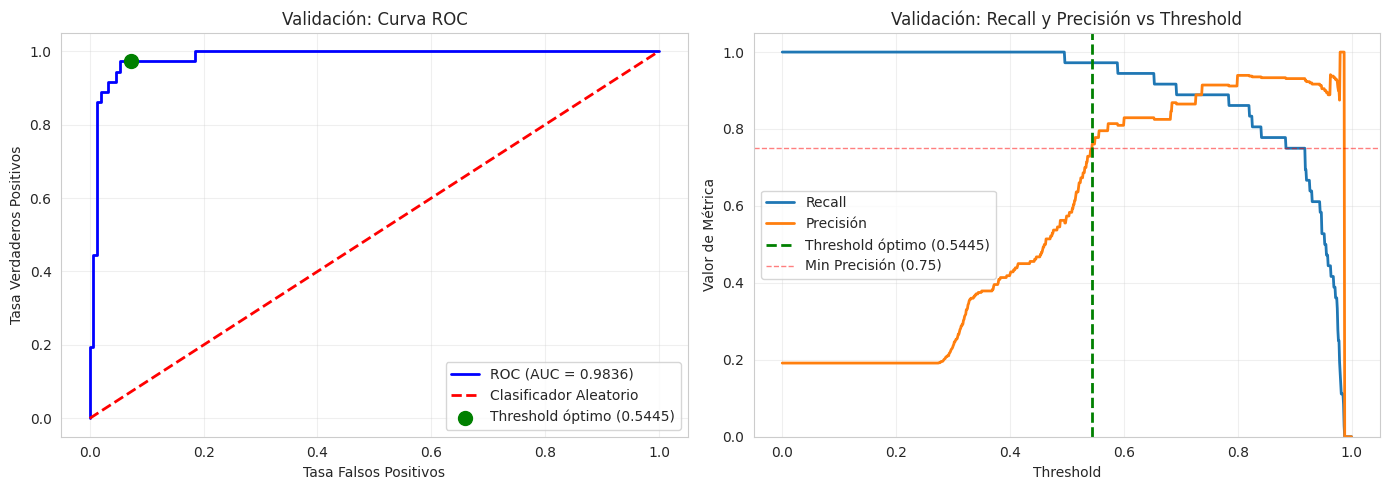

Gráficos guardados


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva ROC
fpr, tpr, thresholds_roc = roc_curve(val_all_labels, val_ensemble_probs)
roc_auc = roc_auc_score(val_all_labels, val_ensemble_probs)

axes[0].plot(fpr, tpr, color='blue', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Clasificador Aleatorio')
axes[0].scatter([1 - best_metrics_val['specificity']], [best_metrics_val['recall']],
                color='green', s=100, marker='o', label=f'Threshold óptimo ({optimal_threshold:.4f})', zorder=5)
axes[0].set_xlabel('Tasa Falsos Positivos')
axes[0].set_ylabel('Tasa Verdaderos Positivos')
axes[0].set_title('Validación: Curva ROC')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Recall vs Threshold
recall_vals = [m['recall'] for m in all_metrics_val]
precision_vals = [m['precision'] for m in all_metrics_val]
threshold_vals = [m['threshold'] for m in all_metrics_val]

axes[1].plot(threshold_vals, recall_vals, label='Recall', linewidth=2)
axes[1].plot(threshold_vals, precision_vals, label='Precisión', linewidth=2)
axes[1].axvline(optimal_threshold, color='green', linestyle='--', linewidth=2, label=f'Threshold óptimo ({optimal_threshold:.4f})')
axes[1].axhline(0.75, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Min Precisión (0.75)')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Valor de Métrica')
axes[1].set_title('Validación: Recall y Precisión vs Threshold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'validacion_threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()

print("Gráficos guardados")

## 8. Matriz de Confusión - Validación

Matriz de confusión de validación:
[[141  11]
 [  1  35]]


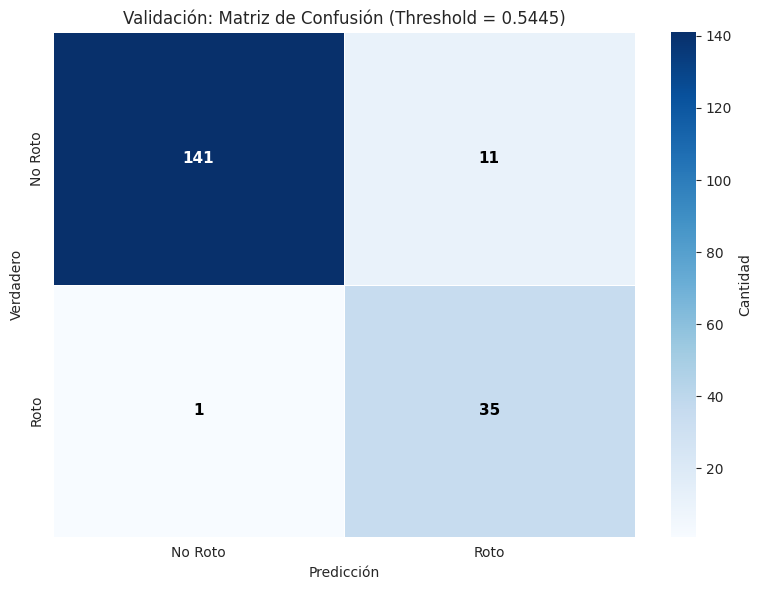

In [8]:
predictions_val = (val_ensemble_probs >= optimal_threshold).astype(int)
cm_val = confusion_matrix(val_all_labels.astype(int), predictions_val.astype(int), labels=[0, 1])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_val, annot=False, fmt='d', cmap='Blues', ax=ax,
            linewidths=0.5, linecolor='white',
            xticklabels=['No Roto', 'Roto'],
            yticklabels=['No Roto', 'Roto'],
            cbar_kws={'label': 'Cantidad'})
threshold = cm_val.max() / 2.0
for i in range(cm_val.shape[0]):
    for j in range(cm_val.shape[1]):
        ax.text(j + 0.5, i + 0.5, format(cm_val[i, j], 'd'),
                ha='center', va='center',
                color='white' if cm_val[i, j] > threshold else 'black',
                fontsize=11, fontweight='bold')
ax.set_xlabel('Predicción')
ax.set_ylabel('Verdadero')
ax.set_title(f'Validación: Matriz de Confusión (Threshold = {optimal_threshold:.4f})')
print('Matriz de confusión de validación:')
print(cm_val)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'validacion_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Evaluación en Test Set

In [9]:
# Cargar datasets de test
test_dataloaders = {}
test_all_labels = None

print("Cargando datasets de test...")
for plane in PLANES:
    test_dataset = OptimizedMRNetDataset(
        csv_path=str(TEST_CSV),
        data_root=str(DATA_DIR / 'test'),
        plane=plane,
        indices_cache_path=str(DATA_DIR / 'slice_indices_final' / f'test_{plane}_indices.json'),
        transform=test_transform
    )
    test_dataloaders[plane] = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)
    print(f"  {plane}: {len(test_dataset)} muestras")

    if test_all_labels is None:
        test_all_labels = test_dataset.df['label'].values

# Predicciones en test
print("\nObteniendo predicciones en test...")
test_predictions = {}

for plane in PLANES:
    probs, labels = get_predictions_on_dataset(cnn_models[plane], test_dataloaders[plane], DEVICE)
    test_predictions[plane] = probs
    auc = roc_auc_score(labels, probs)
    print(f"  {plane}: AUC = {auc:.4f}")

# Ensemble
test_ensemble_probs = ensemble_predictions_weighted(test_predictions, ENSEMBLE_WEIGHTS)
test_ensemble_auc = roc_auc_score(test_all_labels, test_ensemble_probs)

# Métricas con threshold calibrado
test_metrics = calculate_metrics(test_all_labels, test_ensemble_probs, optimal_threshold)

print(f"\nEnsemble (3 planos): AUC = {test_ensemble_auc:.4f}")

print("\n" + "="*80)
print("TEST SET: EVALUACION CON THRESHOLD CALIBRADO")
print("="*80)
print(f"\nThreshold utilizado: {optimal_threshold:.4f} (del validación)")
print(f"\nMétricas:")
print(f"  AUC:          {test_metrics['auc']:.4f}")
print(f"  Precisión:    {test_metrics['precision']:.4f}")
print(f"  Recall:       {test_metrics['recall']:.4f}")
print(f"  F1:           {test_metrics['f1']:.4f}")
print(f"  Exactitud:    {test_metrics['accuracy']:.4f}")
print(f"  Especificidad:{test_metrics['specificity']:.4f}")

print(f"\nMatriz de Confusión:")
print(f"  VP: {test_metrics['tp']:4d}  |  FN: {test_metrics['fn']:4d}")
print(f"  FP: {test_metrics['fp']:4d}  |  VN: {test_metrics['tn']:4d}")

Cargando datasets de test...
 Dataset cargado: 187 casos
  Plane: sagittal
  Augmentation: None (usando transform directo)
  Índices cacheados: /home/palodo2/acl_classifier/data/slice_indices_final/test_sagittal_indices.json
  sagittal: 187 muestras
 Dataset cargado: 187 casos
  Plane: coronal
  Augmentation: None (usando transform directo)
  Índices cacheados: /home/palodo2/acl_classifier/data/slice_indices_final/test_coronal_indices.json
  coronal: 187 muestras
 Dataset cargado: 187 casos
  Plane: axial
  Augmentation: None (usando transform directo)
  Índices cacheados: /home/palodo2/acl_classifier/data/slice_indices_final/test_axial_indices.json
  axial: 187 muestras

Obteniendo predicciones en test...


  sagittal: AUC = 0.8981


  coronal: AUC = 0.8863


  axial: AUC = 0.9390

Ensemble (3 planos): AUC = 0.9545

TEST SET: EVALUACION CON THRESHOLD CALIBRADO

Threshold utilizado: 0.5445 (del validación)

Métricas:
  AUC:          0.9545
  Precisión:    0.6333
  Recall:       0.8837
  F1:           0.7379
  Exactitud:    0.8556
  Especificidad:0.8472

Matriz de Confusión:
  VP:   38  |  FN:    5
  FP:   22  |  VN:  122


## 10. Matriz de Confusión - Test

Matriz de confusión de test:
[[122  22]
 [  5  38]]


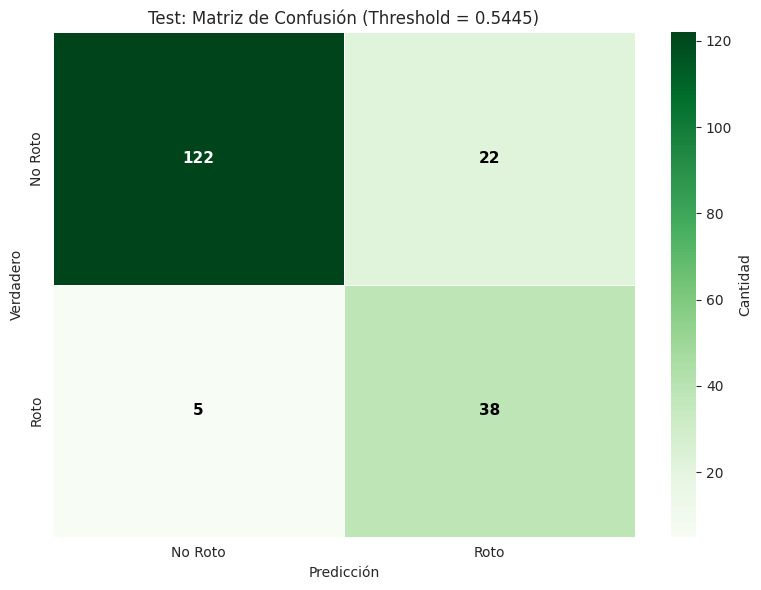

In [10]:
predictions_test = (test_ensemble_probs >= optimal_threshold).astype(int)
cm_test = confusion_matrix(test_all_labels.astype(int), predictions_test.astype(int), labels=[0, 1])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_test, annot=False, fmt='d', cmap='Greens', ax=ax,
            linewidths=0.5, linecolor='white',
            xticklabels=['No Roto', 'Roto'],
            yticklabels=['No Roto', 'Roto'],
            cbar_kws={'label': 'Cantidad'})
threshold = cm_test.max() / 2.0
for i in range(cm_test.shape[0]):
    for j in range(cm_test.shape[1]):
        ax.text(j + 0.5, i + 0.5, format(cm_test[i, j], 'd'),
                ha='center', va='center',
                color='white' if cm_test[i, j] > threshold else 'black',
                fontsize=11, fontweight='bold')
ax.set_xlabel('Predicción')
ax.set_ylabel('Verdadero')
ax.set_title(f'Test: Matriz de Confusión (Threshold = {optimal_threshold:.4f})')
print('Matriz de confusión de test:')
print(cm_test)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'test_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Validación Externa: Croacia (SIN ROI, SAGITTAL SOLO)

In [11]:
print("Cargando dataset de Croacia (sin ROI)...")

if CROATIA_METADATA_CSV.exists():
    croatia_df = pd.read_csv(CROATIA_METADATA_CSV)
    print(f"Volúmenes cargados: {len(croatia_df)}")

 # Distribución de etiquetas
    print(f"\nDistribución de etiquetas:")
    for label in [0, 1]:
        mask = croatia_df['acl_binary_code'] == label
        count = mask.sum()
        pct = 100 * count / len(croatia_df)
        label_name = 'No Roto' if label == 0 else 'Roto'
        print(f"  {label_name}: {count:4d} ({pct:5.1f}%)")

    croatia_indices_cache = build_croatia_sagittal_indices(
        df=croatia_df,
        data_dir=CROATIA_DIR,
        selector_checkpoint=CROATIA_CNN_SELECTOR_PATH,
        output_path=CROATIA_INDICES_CACHE,
        k=CROATIA_SAGITTAL_K,
        force=CROATIA_REGENERATE_INDICES
    )

 # Dataset personalizado para Croacia usando índices sagitales cacheados
    class CroatiaDataset(torch.utils.data.Dataset):
        def __init__(self, df, data_dir, indices_cache, transform=None):
            self.df = df
            self.data_dir = Path(data_dir)
            self.transform = transform
            self.volume_ids = df['volume_id'].values
            self.labels = df['acl_binary_code'].values
            self.indices_cache = indices_cache

        def __len__(self):
            return len(self.df)

        def __getitem__(self, idx):
            volume_id = self.volume_ids[idx]
            label = self.labels[idx]

            filename = f"{volume_id:04d}.npy"
            volume_path = self.data_dir / filename

            volume = np.load(str(volume_path)).astype(np.float32)

 # Usar los índices sagitales precomputados con el selector CNN
            selected_indices = self.indices_cache.get(str(int(volume_id)))
            if selected_indices is None:
                raise KeyError(f"No se encontraron índices cacheados para Croacia: {volume_id}")
            selected_indices = np.array(selected_indices, dtype=int)
            if selected_indices.shape[0] < CROATIA_SAGITTAL_K:
                selected_indices = np.pad(selected_indices, (0, CROATIA_SAGITTAL_K - selected_indices.shape[0]), mode='edge')
            selected_slices = volume[selected_indices]

 # Normalización min-max
            vol_min = selected_slices.min()
            vol_max = selected_slices.max()
            if vol_max > vol_min:
                selected_slices = (selected_slices - vol_min) / (vol_max - vol_min)

 # Tensor y replicar a 3 canales
            selected_slices = torch.from_numpy(selected_slices).float()
            selected_slices = selected_slices.unsqueeze(1).repeat(1, 3, 1, 1)

 # Transformaciones
            if self.transform:
                transformed_slices = []
                for i in range(selected_slices.shape[0]):
                    transformed_slices.append(self.transform(selected_slices[i]))
                selected_slices = torch.stack(transformed_slices, dim=0)

            return selected_slices, torch.tensor(label, dtype=torch.float32), volume_id

 # Crear dataset
    croatia_dataset = CroatiaDataset(
        df=croatia_df,
        data_dir=str(CROATIA_DIR),
        indices_cache=croatia_indices_cache,
        transform=test_transform
    )

    croatia_loader = DataLoader(croatia_dataset, batch_size=32, shuffle=False, num_workers=0)

 # Predicciones: SAGITTAL SOLO
    print(f"\nObteniendo predicciones en Croacia (sin ROI, sagittal)...")
    sagittal_model = cnn_models['sagittal']
    croatia_probs, croatia_labels = get_predictions_on_dataset(
        sagittal_model,
        croatia_loader,
        DEVICE
    )

 # Métricas
    croatia_metrics = calculate_metrics(croatia_labels, croatia_probs, optimal_threshold)

    print("\n" + "="*80)
    print("VALIDACION EXTERNA - CROACIA (SIN ROI, SAGITTAL SOLO)")
    print("="*80)
    print(f"\nVolúmenes: {len(croatia_dataset)}")
    print(f"Threshold utilizado: {optimal_threshold:.4f} (del validación)")
    print(f"\nMétricas:")
    print(f"  AUC:          {croatia_metrics['auc']:.4f}")
    print(f"  Precisión:    {croatia_metrics['precision']:.4f}")
    print(f"  Recall:       {croatia_metrics['recall']:.4f}")
    print(f"  F1:           {croatia_metrics['f1']:.4f}")
    print(f"  Exactitud:    {croatia_metrics['accuracy']:.4f}")
    print(f"  Especificidad:{croatia_metrics['specificity']:.4f}")

    print(f"\nMatriz de Confusión:")
    print(f"  VP: {croatia_metrics['tp']:4d}  |  FN: {croatia_metrics['fn']:4d}")
    print(f"  FP: {croatia_metrics['fp']:4d}  |  VN: {croatia_metrics['tn']:4d}")

else:
    print(f"Erro: No se encontró la metadata de Croacia en {CROATIA_METADATA_CSV}")

Cargando dataset de Croacia (sin ROI)...
Volúmenes cargados: 917

Distribución de etiquetas:
  No Roto:  690 ( 75.2%)
  Roto:  227 ( 24.8%)
Generando índices sagitales de Croacia con CNN Selector (K=5)...
 CNN Selector cargado desde: /home/palodo2/acl_classifier/checkpoints/acl_slice_classifier_v3/best_model_f1.pth
  Validation F1: 0.8563
  Device: cuda


  Progreso: 25/917 (3%)


  Progreso: 50/917 (5%)


  Progreso: 75/917 (8%)


  Progreso: 100/917 (11%)


...

  Progreso: 850/917 (93%)


  Progreso: 875/917 (95%)


  Progreso: 900/917 (98%)


  Progreso: 917/917 (100%)
Índices sagitales guardados en: /home/palodo2/acl_classifier/data/slice_indices_final/croatia_sagittal_indices_full.json

Obteniendo predicciones en Croacia (sin ROI, sagittal)...



VALIDACION EXTERNA - CROACIA (SIN ROI, SAGITTAL SOLO)

Volúmenes: 917
Threshold utilizado: 0.5445 (del validación)

Métricas:
  AUC:          0.7847
  Precisión:    0.8699
  Recall:       0.5595
  F1:           0.6810
  Exactitud:    0.8702
  Especificidad:0.9725

Matriz de Confusión:
  VP:  127  |  FN:  100
  FP:   19  |  VN:  671


## 12. Matriz de Confusión - Croacia

Matriz de confusión de Croacia:
[[671  19]
 [100 127]]


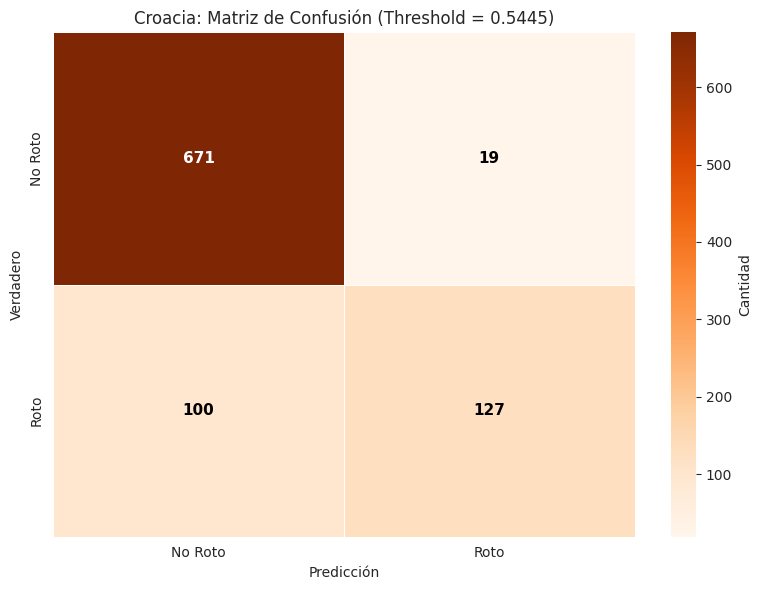

In [12]:
predictions_croatia = (croatia_probs >= optimal_threshold).astype(int)
cm_croatia = confusion_matrix(croatia_labels, predictions_croatia, labels=[0, 1])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_croatia, annot=False, fmt='d', cmap='Oranges', ax=ax,
            linewidths=0.5, linecolor='white',
            xticklabels=['No Roto', 'Roto'],
            yticklabels=['No Roto', 'Roto'],
            cbar_kws={'label': 'Cantidad'})
threshold = cm_croatia.max() / 2.0
for i in range(cm_croatia.shape[0]):
    for j in range(cm_croatia.shape[1]):
        ax.text(j + 0.5, i + 0.5, format(cm_croatia[i, j], 'd'),
                ha='center', va='center',
                color='white' if cm_croatia[i, j] > threshold else 'black',
                fontsize=11, fontweight='bold')
ax.set_xlabel('Predicción')
ax.set_ylabel('Verdadero')
ax.set_title(f'Croacia: Matriz de Confusión (Threshold = {optimal_threshold:.4f})')
print('Matriz de confusión de Croacia:')
print(cm_croatia)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'croacia_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Comparación Generalización y Domain Shift

In [13]:
# Tabla comparativa
comparison_data = {
    'Dataset': ['Validación', 'Test', 'Croacia'],
    'Muestras': [len(val_all_labels), len(test_all_labels), len(croatia_labels)],
    'AUC': [best_metrics_val['auc'], test_metrics['auc'], croatia_metrics['auc']],
    'Precisión': [best_metrics_val['precision'], test_metrics['precision'], croatia_metrics['precision']],
    'Recall': [best_metrics_val['recall'], test_metrics['recall'], croatia_metrics['recall']],
    'Especificidad': [best_metrics_val['specificity'], test_metrics['specificity'], croatia_metrics['specificity']]
}

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*80)
print("RESUMEN COMPARATIVO")
print("="*80)
print(comparison_df.to_string(index=False))

# Domain shift
auc_drop_test = (best_metrics_val['auc'] - test_metrics['auc']) * 100
auc_drop_croatia = (test_metrics['auc'] - croatia_metrics['auc']) * 100

print(f"\n" + "="*80)
print("ANALISIS DE GENERALIZACION")
print("="*80)
print(f"\nCaída AUC (Validación -> Test):    {auc_drop_test:+.2f}%")
print(f"Caída AUC (Test -> Croacia):       {auc_drop_croatia:+.2f}%")
print(f"Caída Total (Validación -> Croacia): {(best_metrics_val['auc'] - croatia_metrics['auc'])*100:+.2f}%")

if croatia_metrics['auc'] > 0.80:
    print(f"\nConclusión: Excelente generalización (AUC > 0.80)")
elif croatia_metrics['auc'] > 0.75:
    print(f"\nConclusión: Buena generalización (AUC > 0.75)")
elif croatia_metrics['auc'] > 0.70:
    print(f"\nConclusión: Generalización aceptable (AUC > 0.70)")
else:
    print(f"\nConclusión: Domain shift significativo (AUC < 0.70)")


RESUMEN COMPARATIVO
   Dataset  Muestras      AUC  Precisión   Recall  Especificidad
Validación       188 0.983553   0.760870 0.972222       0.927632
      Test       187 0.954457   0.633333 0.883721       0.847222
   Croacia       917 0.784690   0.869863 0.559471       0.972464

ANALISIS DE GENERALIZACION

Caída AUC (Validación -> Test):    +2.91%
Caída AUC (Test -> Croacia):       +16.98%
Caída Total (Validación -> Croacia): +19.89%

Conclusión: Buena generalización (AUC > 0.75)


## 14. Gráfico Comparativo: Curvas ROC

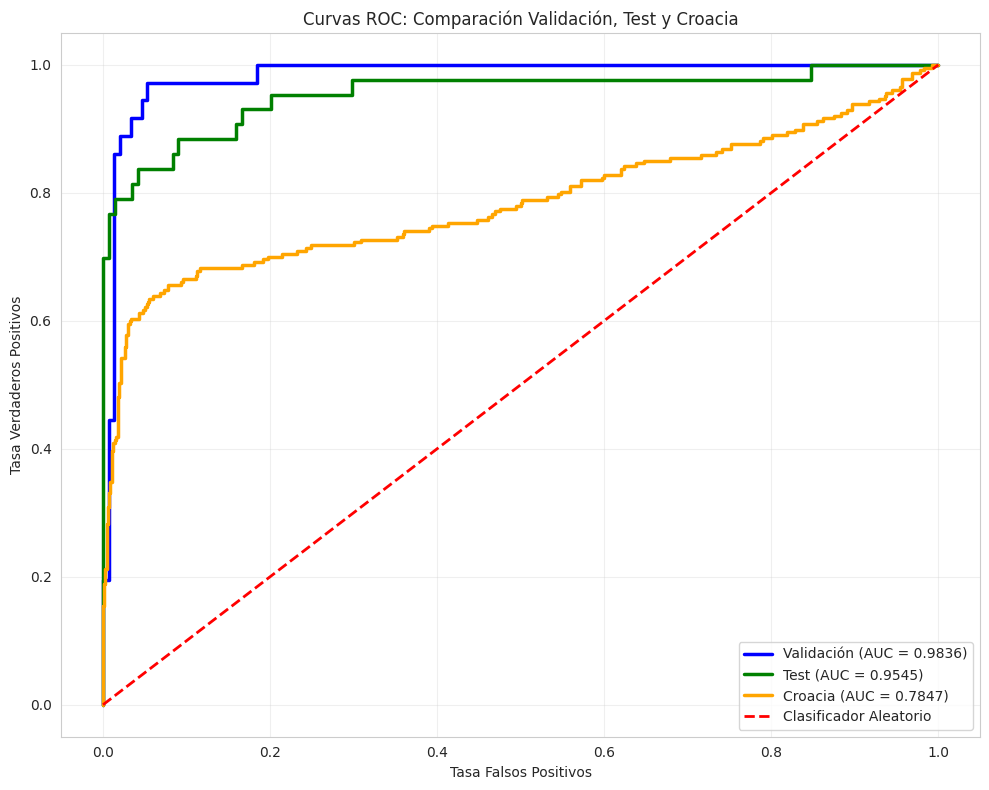

Gráfico de comparación de ROC guardado


In [14]:
fig, ax = plt.subplots(figsize=(10, 8))

# Curvas ROC
fpr_val, tpr_val, _ = roc_curve(val_all_labels, val_ensemble_probs)
roc_auc_val = roc_auc_score(val_all_labels, val_ensemble_probs)

fpr_test, tpr_test, _ = roc_curve(test_all_labels, test_ensemble_probs)
roc_auc_test = roc_auc_score(test_all_labels, test_ensemble_probs)

fpr_croatia, tpr_croatia, _ = roc_curve(croatia_labels, croatia_probs)
roc_auc_croatia = roc_auc_score(croatia_labels, croatia_probs)

ax.plot(fpr_val, tpr_val, color='blue', lw=2.5, label=f'Validación (AUC = {roc_auc_val:.4f})')
ax.plot(fpr_test, tpr_test, color='green', lw=2.5, label=f'Test (AUC = {roc_auc_test:.4f})')
ax.plot(fpr_croatia, tpr_croatia, color='orange', lw=2.5, label=f'Croacia (AUC = {roc_auc_croatia:.4f})')
ax.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Clasificador Aleatorio')

ax.set_xlabel('Tasa Falsos Positivos')
ax.set_ylabel('Tasa Verdaderos Positivos')
ax.set_title('Curvas ROC: Comparación Validación, Test y Croacia')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'comparacion_curvas_roc.png', dpi=150, bbox_inches='tight')
plt.show()

print("Gráfico de comparación de ROC guardado")

## 15. Gráfico Comparativo: Métricas

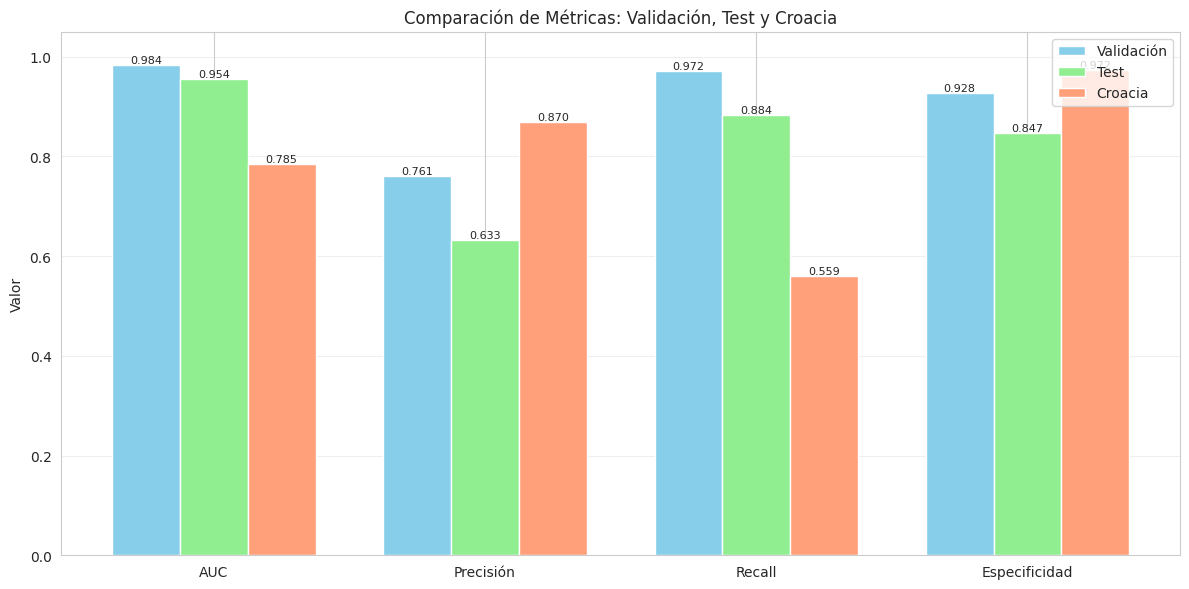

Gráfico de comparación de métricas guardado


In [15]:
metrics_names = ['AUC', 'Precisión', 'Recall', 'Especificidad']
val_vals = [best_metrics_val['auc'], best_metrics_val['precision'], best_metrics_val['recall'], best_metrics_val['specificity']]
test_vals = [test_metrics['auc'], test_metrics['precision'], test_metrics['recall'], test_metrics['specificity']]
croatia_vals = [croatia_metrics['auc'], croatia_metrics['precision'], croatia_metrics['recall'], croatia_metrics['specificity']]

x = np.arange(len(metrics_names))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width, val_vals, width, label='Validación', color='skyblue')
bars2 = ax.bar(x, test_vals, width, label='Test', color='lightgreen')
bars3 = ax.bar(x + width, croatia_vals, width, label='Croacia', color='lightsalmon')

ax.set_ylabel('Valor')
ax.set_title('Comparación de Métricas: Validación, Test y Croacia')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 1.05])

# Añadir valores en las barras
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'comparacion_metricas.png', dpi=150, bbox_inches='tight')
plt.show()

print("Gráfico de comparación de métricas guardado")

## 16. Fine-tuning de Croacia con split train/val/test

En esta sección separo Croacia en train/val/test, evalúo el test antes del fine-tuning, hago fine-tuning con train/val y vuelvo a evaluar el test para medir la mejora real.

In [16]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import copy
import pickle
import json

SPLIT_RANDOM_STATE = 42
CROATIA_SPLIT_DIR = CROATIA_DIR / 'splits'
CROATIA_SPLIT_DIR.mkdir(parents=True, exist_ok=True)
CROATIA_SPLIT_INDICES_DIR = CROATIA_SPLIT_DIR / 'slice_indices'
CROATIA_SPLIT_INDICES_DIR.mkdir(parents=True, exist_ok=True)

split_source_df = croatia_df.copy()
if 'new_filename' in split_source_df.columns:
    split_source_df = split_source_df.rename(columns={'new_filename': 'filename'})
if 'acl_binary_code' not in split_source_df.columns:
    raise KeyError('No se encontró la columna acl_binary_code en croatia_df')

split_source_df = split_source_df[['volume_id', 'filename', 'acl_binary_code']].copy()
split_source_df['label'] = split_source_df['acl_binary_code'].astype(int)
split_source_df['case_id'] = split_source_df['volume_id'].astype(str)

train_df, temp_df = train_test_split(
    split_source_df,
    test_size=0.30,
    random_state=SPLIT_RANDOM_STATE,
    stratify=split_source_df['label']
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SPLIT_RANDOM_STATE,
    stratify=temp_df['label']
)

train_df = train_df.sort_values('volume_id').reset_index(drop=True)
val_df = val_df.sort_values('volume_id').reset_index(drop=True)
test_df = test_df.sort_values('volume_id').reset_index(drop=True)

for split_name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    csv_path = CROATIA_SPLIT_DIR / f'{split_name}.csv'
    df[['volume_id', 'filename', 'label']].to_csv(csv_path, index=False)
    print(f' {split_name}: {len(df)} casos -> {csv_path}')

print('\nDistribución de clases:')
for split_name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(f"- {split_name}: {df['label'].value_counts().to_dict()}")


 train: 641 casos -> /home/palodo2/acl_classifier/data/croatia_npy_volumes_full/splits/train.csv
 val: 138 casos -> /home/palodo2/acl_classifier/data/croatia_npy_volumes_full/splits/val.csv
 test: 138 casos -> /home/palodo2/acl_classifier/data/croatia_npy_volumes_full/splits/test.csv

Distribución de clases:
- train: {0: 482, 1: 159}
- val: {0: 104, 1: 34}
- test: {0: 104, 1: 34}


In [17]:
from tqdm import tqdm

def load_croatia_npy_volume(volume_path):
    volume = np.load(volume_path).astype(np.float32)
    vol_min = volume.min()
    vol_max = volume.max()
    if vol_max > vol_min:
        volume = (volume - vol_min) / (vol_max - vol_min)
    return volume


def build_croatia_split_indices(split_df, split_name, selector, k=CROATIA_SAGITTAL_K):
    output_path = CROATIA_SPLIT_INDICES_DIR / f'{split_name}_sagittal_indices.json'
    if output_path.exists() and not CROATIA_REGENERATE_INDICES:
        with open(output_path, 'r') as f:
            return json.load(f)

    indices_dict = {}
    for _, row in tqdm(split_df.iterrows(), total=len(split_df), desc=f'Indices {split_name}'):
        volume_path = CROATIA_DIR / row['filename']
        volume = load_croatia_npy_volume(volume_path)
        probs = [selector.get_acl_probability(volume[slice_idx]) for slice_idx in range(volume.shape[0])]
        if len(probs) <= k:
            selected = list(range(len(probs)))
            while len(selected) < k:
                selected.append(selected[-1])
            selected = selected[:k]
        else:
            selected = np.argsort(probs)[-k:].tolist()
            selected = sorted(selected)
        indices_dict[str(row['volume_id'])] = selected

    with open(output_path, 'w') as f:
        json.dump(indices_dict, f, indent=2)
    return indices_dict


class CroatiaSplitDataset(Dataset):
    def __init__(self, csv_path, data_dir, indices_cache_path, transform=None):
        self.df = pd.read_csv(csv_path)
        self.data_dir = Path(data_dir)
        self.transform = transform
        with open(indices_cache_path, 'r') as f:
            self.indices_cache = json.load(f)

    def __len__(self):
        return len(self.df)

    def _load_volume(self, volume_path):
        return load_croatia_npy_volume(volume_path)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        volume_path = self.data_dir / row['filename']
        volume = self._load_volume(volume_path)
        selected_indices = self.indices_cache[str(row['volume_id'])]
        selected_slices = volume[selected_indices]
        selected_slices = torch.from_numpy(selected_slices).float().unsqueeze(1).repeat(1, 3, 1, 1)
        if self.transform is not None:
            selected_slices = torch.stack([self.transform(slice_img) for slice_img in selected_slices], dim=0)
        label = torch.tensor(float(row['label']), dtype=torch.float32)
        return selected_slices, label, str(row['volume_id'])


train_transform_ft = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_test_transform_ft = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

cnn_selector = SimpleCNNSelector(CROATIA_CNN_SELECTOR_PATH, device=str(DEVICE))

train_indices = build_croatia_split_indices(train_df, 'train', cnn_selector)
val_indices = build_croatia_split_indices(val_df, 'val', cnn_selector)
test_indices = build_croatia_split_indices(test_df, 'test', cnn_selector)

train_dataset_ft = CroatiaSplitDataset(CROATIA_SPLIT_DIR / 'train.csv', CROATIA_DIR, CROATIA_SPLIT_INDICES_DIR / 'train_sagittal_indices.json', transform=train_transform_ft)
val_dataset_ft = CroatiaSplitDataset(CROATIA_SPLIT_DIR / 'val.csv', CROATIA_DIR, CROATIA_SPLIT_INDICES_DIR / 'val_sagittal_indices.json', transform=val_test_transform_ft)
test_dataset_ft = CroatiaSplitDataset(CROATIA_SPLIT_DIR / 'test.csv', CROATIA_DIR, CROATIA_SPLIT_INDICES_DIR / 'test_sagittal_indices.json', transform=val_test_transform_ft)

train_loader_ft = DataLoader(train_dataset_ft, batch_size=16, shuffle=True, num_workers=4, pin_memory=torch.cuda.is_available())
val_loader_ft = DataLoader(val_dataset_ft, batch_size=16, shuffle=False, num_workers=4, pin_memory=torch.cuda.is_available())
test_loader_ft = DataLoader(test_dataset_ft, batch_size=16, shuffle=False, num_workers=4, pin_memory=torch.cuda.is_available())

print(f'Train loader: {len(train_dataset_ft)} casos')
print(f'Val loader: {len(val_dataset_ft)} casos')
print(f'Test loader: {len(test_dataset_ft)} casos')


 CNN Selector cargado desde: /home/palodo2/acl_classifier/checkpoints/acl_slice_classifier_v3/best_model_f1.pth
  Validation F1: 0.8563
  Device: cuda


Indices train:   0%|             | 0/641 [00:00<?, ?it/s]

Indices train:   0%|     | 1/641 [00:00<08:22,  1.27it/s]

Indices train:   0%|     | 2/641 [00:01<06:32,  1.63it/s]

Indices train:   0%|     | 3/641 [00:01<05:32,  1.92it/s]

...

Indices test:  99%|███▉| 136/138 [01:17<00:01,  1.53it/s]

Indices test:  99%|███▉| 137/138 [01:18<00:00,  1.50it/s]

Indices test: 100%|████| 138/138 [01:18<00:00,  1.56it/s]

Indices test: 100%|████| 138/138 [01:18<00:00,  1.75it/s]

Train loader: 641 casos
Val loader: 138 casos
Test loader: 138 casos


BASELINE TEST ANTES DEL FINE-TUNING (SAGITTAL)


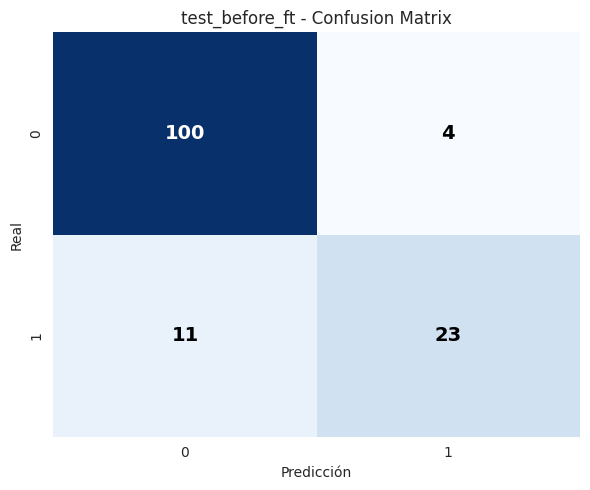

test_before_ft: {'auc': np.float64(0.8518099547511311), 'accuracy': np.float64(0.8913043478260869), 'precision': np.float64(0.8518518518518519), 'recall': np.float64(0.6764705882352942), 'specificity': np.float64(0.9615384615384616), 'f1': np.float64(0.7540983606557378), 'tp': np.int64(23), 'tn': np.int64(100), 'fp': np.int64(4), 'fn': np.int64(11)}
Baseline sagittal AUC: 0.8518

FINE-TUNING CNN SAGITTAL CON CROACIA TRAIN/VAL

ENTRENANDO MODELO: SAGITTAL_CROATIA
LR=0.0002, WD=0.0001, Scheduler=False, GradClip=True
Dropout: Input=0.3, Dense=0.2
Augmentation: conservative



 Class imbalance (pos_weight): 3.0314
   (Ratio negatives:positives × 1.0)

   Backbone frozen - training only classifier head
Epoch 1/30 (LR=2.00e-04):

Train: Loss=0.8463, AUC=0.8083 | Val: Loss=0.7057, AUC=0.8592, F1=0.6479  Best AUC!
Epoch 2/30 (LR=2.00e-04):

Train: Loss=0.7949, AUC=0.8343 | Val: Loss=0.7146, AUC=0.8640, F1=0.6774  Best AUC!
Epoch 3/30 (LR=2.00e-04):

Train: Loss=0.8350, AUC=0.8388 | Val: Loss=0.7213, AUC=0.8671, F1=0.6774  Best AUC!
Epoch 4/30 (LR=2.00e-04):

...

Train: Loss=0.7296, AUC=0.8480 | Val: Loss=0.6985, AUC=0.8727, F1=0.6875
Epoch 7/30 (LR=1.00e-04):

Train: Loss=0.7868, AUC=0.8478 | Val: Loss=0.6895, AUC=0.8722, F1=0.6970  LR Reduced: 1.00e-04  5.00e-05
Epoch 8/30 (LR=5.00e-05):

Train: Loss=0.6938, AUC=0.8640 | Val: Loss=0.6862, AUC=0.8722, F1=0.6765  LR Reduced: 5.00e-05  2.50e-05
Epoch 9/30 (LR=2.50e-05):

Train: Loss=0.6909, AUC=0.8710 | Val: Loss=0.6871, AUC=0.8716, F1=0.6667  LR Reduced: 2.50e-05  1.25e-05
Epoch 10/30 (LR=1.25e-05):

Train: Loss=0.8002, AUC=0.8563 | Val: Loss=0.7176, AUC=0.8730, F1=0.6984

  Early stopping: sin mejora en 6 epochs.

 ENTRENAMIENTO COMPLETADO: SAGITTAL_CROATIA
  Mejor AUC: 0.8764
  Mejor F1:  0.6970
  Augmentation: conservative


TEST ORIGINAL DESPUÉS DEL FINE-TUNING (SAGITTAL)


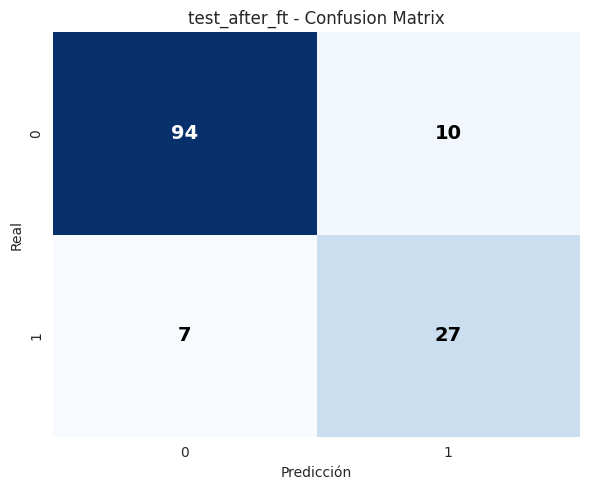

test_after_ft: {'auc': np.float64(0.8993212669683258), 'accuracy': np.float64(0.8768115942028986), 'precision': np.float64(0.7297297297297297), 'recall': np.float64(0.7941176470588235), 'specificity': np.float64(0.9038461538461539), 'f1': np.float64(0.7605633802816901), 'tp': np.int64(27), 'tn': np.int64(94), 'fp': np.int64(10), 'fn': np.int64(7)}
Post-finetune sagittal AUC: 0.8993
Best val AUC: 0.8764 | Best val F1: 0.6970


In [18]:
import sys
import copy

sys.path.append(str(Path(BASE_DIR) / '..'))
sys.path.append(str(Path(BASE_DIR) / 'src'))
import src.models as _src_models
sys.modules['models'] = _src_models

from src.training_utils import train_model
from sklearn.metrics import roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


def save_predictions_and_cm(split_name, labels, probs, output_dir, threshold):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    preds = (probs >= threshold).astype(int)
    cm = confusion_matrix(labels.astype(int), preds.astype(int), labels=[0, 1])

    pd.DataFrame({
        'label': labels.astype(int),
        'probability': probs,
        'prediction': preds,
    }).to_csv(output_dir / f'{split_name}_predictions.csv', index=False)

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')
    ax.set_title(f'{split_name} - Confusion Matrix')
    threshold_value = cm.max() / 2.0 if cm.max() > 0 else 0
    for row_idx in range(cm.shape[0]):
        for col_idx in range(cm.shape[1]):
            value = cm[row_idx, col_idx]
            color = 'white' if value > threshold_value else 'black'
            ax.text(col_idx + 0.5, row_idx + 0.5, str(value), ha='center', va='center', color=color, fontsize=14, fontweight='bold')
    plt.tight_layout()
    fig.savefig(output_dir / f'{split_name}_confusion_matrix.png', dpi=200, bbox_inches='tight')
    plt.show()

    metrics = calculate_metrics(labels, probs, threshold=threshold)
    print(f'{split_name}: {metrics}')
    return metrics


print('=' * 80)
print('BASELINE TEST ANTES DEL FINE-TUNING (SAGITTAL)')
print('=' * 80)

baseline_test_probs, baseline_test_labels = get_predictions_on_dataset(
    cnn_models['sagittal'],
    test_loader_ft,
    DEVICE,
)
baseline_test_metrics = save_predictions_and_cm(
    'test_before_ft',
    baseline_test_labels,
    baseline_test_probs,
    CROATIA_SPLIT_DIR / 'baseline_results',
    optimal_threshold,
)
print(f'Baseline sagittal AUC: {roc_auc_score(baseline_test_labels, baseline_test_probs):.4f}')

print('\n' + '=' * 80)
print('FINE-TUNING CNN SAGITTAL CON CROACIA TRAIN/VAL')
print('=' * 80)

ft_model = copy.deepcopy(cnn_models['sagittal']).to(DEVICE)
ft_save_dir = CROATIA_SPLIT_DIR / 'finetune_checkpoints'
history, best_auc_ft, best_f1_ft = train_model(
    ft_model,
    train_loader_ft,
    val_loader_ft,
    num_epochs=30,
    device=DEVICE,
    save_dir=ft_save_dir,
    plane_name='sagittal_croatia',
    learning_rate=2e-4,
    weight_decay=1e-4,
    label_smoothing=0.02,
    use_scheduler=False,
    use_grad_clip=True,
    grad_clip_norm=1.0,
    early_stopping_patience=6,
    freeze_backbone_epochs=30,
    use_lr_plateau_scheduler=True,
    lr_plateau_patience=1,
)

best_checkpoint_path = ft_save_dir / 'best_sagittal_croatia_auc.pth'
checkpoint_ft = torch.load(best_checkpoint_path, map_location=DEVICE, weights_only=False)
ft_model.load_state_dict(checkpoint_ft['model_state_dict'], strict=False)
ft_model = ft_model.to(DEVICE)

print('\n' + '=' * 80)
print('TEST ORIGINAL DESPUÉS DEL FINE-TUNING (SAGITTAL)')
print('=' * 80)

post_test_probs, post_test_labels = get_predictions_on_dataset(
    ft_model,
    test_loader_ft,
    DEVICE,
)
post_test_metrics = save_predictions_and_cm(
    'test_after_ft',
    post_test_labels,
    post_test_probs,
    CROATIA_SPLIT_DIR / 'finetune_results',
    optimal_threshold,
)
print(f'Post-finetune sagittal AUC: {roc_auc_score(post_test_labels, post_test_probs):.4f}')
print(f'Best val AUC: {best_auc_ft:.4f} | Best val F1: {best_f1_ft:.4f}')

# Obtener predicciones en la validación de Croacia para tunear el threshold
val_probs_ft, val_labels_ft = get_predictions_on_dataset(
    ft_model,
    val_loader_ft,
    DEVICE,
)


## 17. Gráficas de Entrenamiento

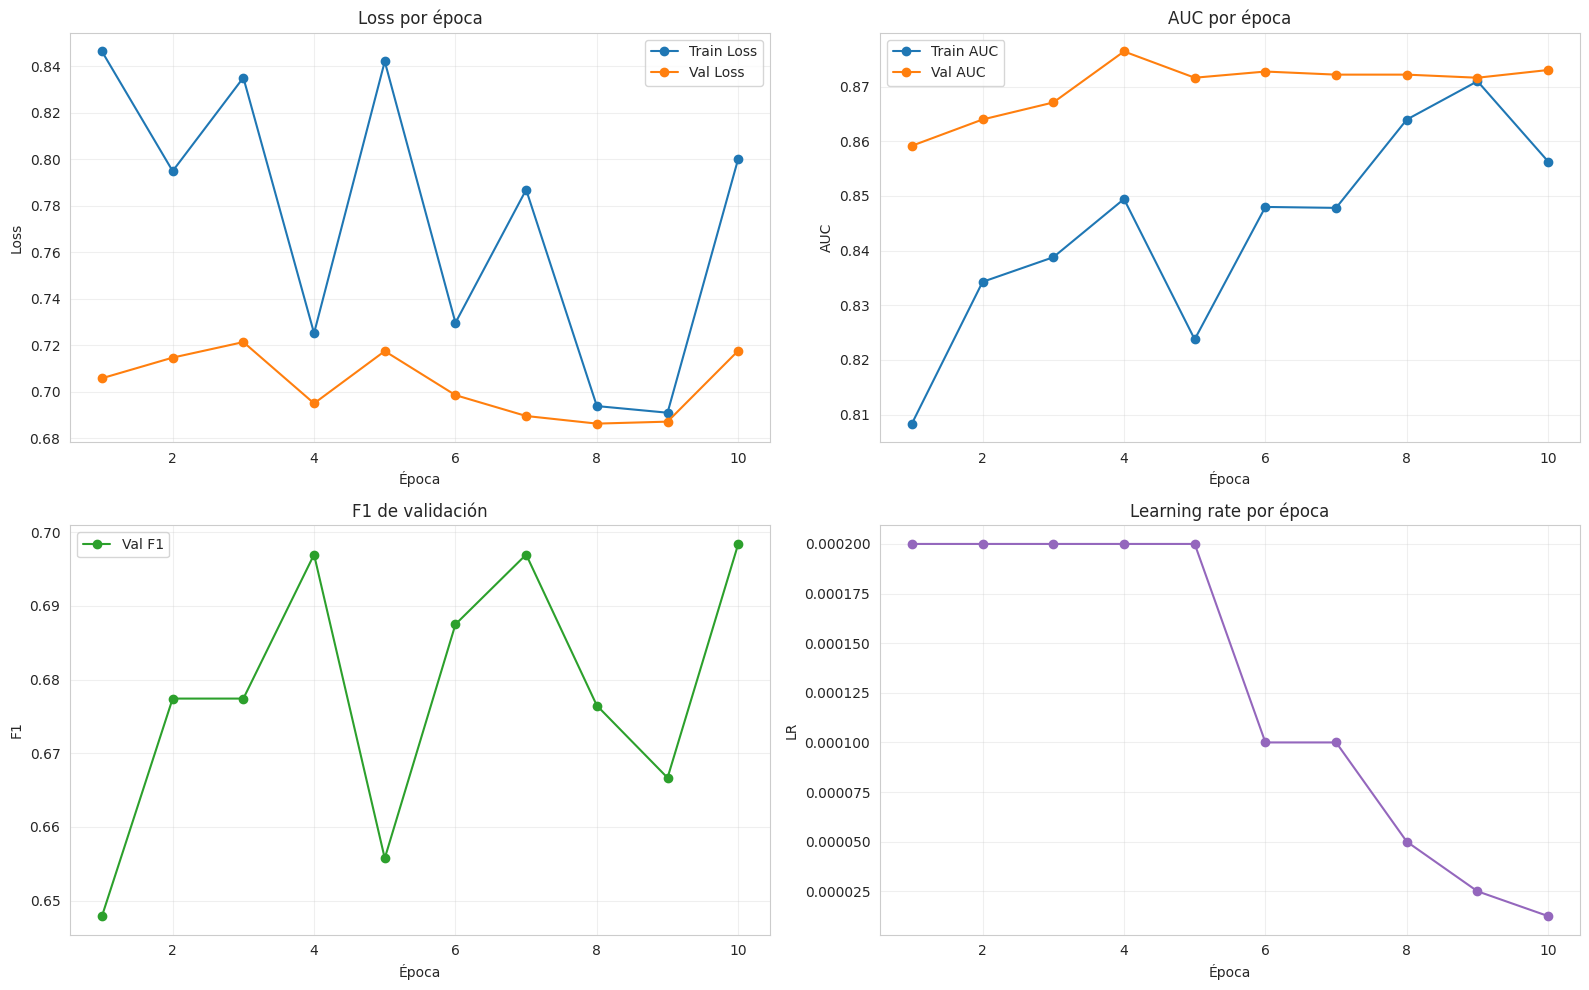

Gráficas de entrenamiento guardadas en: /home/palodo2/acl_classifier/data/croatia_npy_volumes_full/splits/training_curves.png


In [19]:
epochs = np.arange(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

axes[0].plot(epochs, history['train_loss'], marker='o', label='Train Loss')
axes[0].plot(epochs, history['val_loss_objective'], marker='o', label='Val Loss')
axes[0].set_title('Loss por época')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history['train_auc'], marker='o', label='Train AUC')
axes[1].plot(epochs, history['val_auc'], marker='o', label='Val AUC')
axes[1].set_title('AUC por época')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('AUC')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs, history['val_f1'], marker='o', color='tab:green', label='Val F1')
axes[2].set_title('F1 de validación')
axes[2].set_xlabel('Época')
axes[2].set_ylabel('F1')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

axes[3].plot(epochs, history['learning_rates'], marker='o', color='tab:purple')
axes[3].set_title('Learning rate por época')
axes[3].set_xlabel('Época')
axes[3].set_ylabel('LR')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(CROATIA_SPLIT_DIR / 'training_curves.png', dpi=200, bbox_inches='tight')
plt.show()

print('Gráficas de entrenamiento guardadas en:', CROATIA_SPLIT_DIR / 'training_curves.png')

## Ajuste de threshold usando validación del fine‑tuning

Se calcula el umbral óptimo en la validación del fine‑tuning (maximizando F1) y se aplica al conjunto de test. Se guardan predicciones y la matriz de confusión en el directorio de resultados del fine‑tuning.

In [20]:
# Compute optimal threshold on fine-tune validation (maximize F1)
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_curve
from pathlib import Path
import json

# helper to fetch validation probs/labels from common notebook variables
def _get(vars_list):
    for n in vars_list:
        if n in globals():
            return globals()[n]
    return None

probs = _get(['val_probs_ft', 'val_ensemble_probs', 'val_probs'])
labels = _get(['val_labels_ft', 'val_all_labels', 'val_labels'])
if probs is None or labels is None:
    if 'val_predictions' in globals():
        vp = val_predictions
        if isinstance(vp, dict):
            probs = np.array(vp.get('probs') or vp.get('prob') or vp.get('pred_prob'))
            labels = np.array(vp.get('labels') or vp.get('y') or vp.get('true'))

if probs is None or labels is None:
    raise RuntimeError('No validation probabilities/labels found in notebook namespace.')

probs = np.asarray(probs).ravel()
labels = np.asarray(labels).ravel().astype(int)

prec, rec, thr = precision_recall_curve(labels, probs)
if len(thr) == 0:
    best_thr = float(0.5)
else:
    f1s = 2*prec[:-1]*rec[:-1]/(prec[:-1]+rec[:-1]+1e-8)
    best_idx = int(np.nanargmax(f1s))
    best_thr = float(thr[best_idx])

print(f"Selected threshold (F1-max): {best_thr:.4f}")

# compute validation metrics at best_thr
if 'calculate_metrics' in globals():
    val_metrics = calculate_metrics(labels, probs, best_thr)
else:
    from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, accuracy_score, confusion_matrix
    preds = (probs>=best_thr).astype(int)
    val_metrics = {
        'auc': float(roc_auc_score(labels, probs)),
        'accuracy': float(accuracy_score(labels, preds)),
        'precision': float(precision_score(labels, preds)),
        'recall': float(recall_score(labels, preds)),
        'f1': float(f1_score(labels, preds)),
        'confusion_matrix': confusion_matrix(labels, preds).tolist(),
        'tp': int(((preds==1)&(labels==1)).sum()),
        'tn': int(((preds==0)&(labels==0)).sum()),
        'fp': int(((preds==1)&(labels==0)).sum()),
        'fn': int(((preds==0)&(labels==1)).sum())
    }
print(val_metrics)

# helper to convert numpy types to python types

def to_py(o):
    if isinstance(o, np.ndarray):
        return o.tolist()
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, (np.floating,)):
        return float(o)
    if isinstance(o, dict):
        return {k: to_py(v) for k, v in o.items()}
    if isinstance(o, list):
        return [to_py(v) for v in o]
    return o

# save threshold and val preds
out_dir = Path(ft_save_dir) if 'ft_save_dir' in globals() else DATA_DIR / 'croatia_npy_volumes_full' / 'splits' / 'finetune_results'
out_dir.mkdir(parents=True, exist_ok=True)
json.dump({'best_threshold':best_thr, 'val_metrics': to_py(val_metrics)}, open(out_dir/'selected_threshold.json','w'))
df_val = pd.DataFrame({'label':labels, 'prob':probs, 'pred':(probs>=best_thr).astype(int)})
df_val.to_csv(out_dir/'val_predictions_with_selected_threshold.csv', index=False)


Selected threshold (F1-max): 0.5055
{'auc': np.float64(0.8764140271493213), 'accuracy': np.float64(0.8623188405797102), 'precision': np.float64(0.7419354838709677), 'recall': np.float64(0.6764705882352942), 'specificity': np.float64(0.9230769230769231), 'f1': np.float64(0.7076923076923077), 'tp': np.int64(23), 'tn': np.int64(96), 'fp': np.int64(8), 'fn': np.int64(11)}


Loaded selected threshold from /home/palodo2/acl_classifier/data/croatia_npy_volumes_full/splits/finetune_checkpoints/selected_threshold.json -> 0.5054576396942139
{'roc_auc': 0.8993212669683258, 'accuracy': 0.8768115942028986, 'precision': 0.717948717948718, 'recall': 0.8235294117647058, 'f1': 0.7671232876712328, 'confusion_matrix': [[93, 11], [6, 28]]}


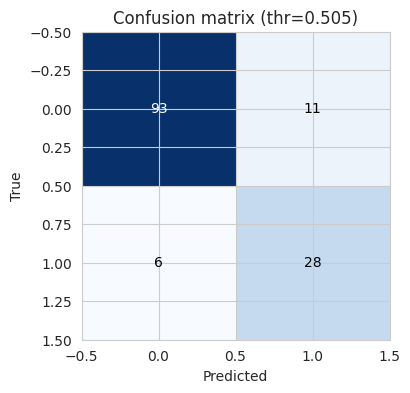

In [21]:
# Apply selected threshold to test set and save results (robust: compute if missing)
import numpy as np
import pandas as pd
from pathlib import Path
import json
from sklearn.metrics import confusion_matrix, roc_auc_score, f1_score, precision_score, recall_score, accuracy_score
from sklearn.metrics import precision_recall_curve

# determine out_dir
out_dir = Path(ft_save_dir) if 'ft_save_dir' in globals() else DATA_DIR / 'croatia_npy_volumes_full' / 'splits' / 'finetune_results'
out_dir.mkdir(parents=True, exist_ok=True)
selected_path = out_dir / 'selected_threshold.json'

best_thr = None
if selected_path.exists():
    sel = json.load(open(selected_path))
 # support both keys
    best_thr = float(sel.get('best_threshold') or sel.get('threshold'))
    print('Loaded selected threshold from', selected_path, '->', best_thr)
else:
 # compute from validation variables if available
    print('selected_threshold.json not found — intentar calcular umbral desde validación en memoria')
    def _get(vars_list):
        for n in vars_list:
            if n in globals():
                return globals()[n]
        return None
    probs = _get(['val_probs_ft', 'val_ensemble_probs', 'val_probs'])
    labels = _get(['val_labels_ft', 'val_all_labels', 'val_labels'])
    if probs is None or labels is None:
        raise RuntimeError('No hay probs/labels de validación en memoria y no existe selected_threshold.json')
    probs = np.asarray(probs).ravel()
    labels = np.asarray(labels).ravel().astype(int)
    prec, rec, thr = precision_recall_curve(labels, probs)
    if len(thr) == 0:
        best_thr = 0.5
    else:
        f1s = 2*prec[:-1]*rec[:-1]/(prec[:-1]+rec[:-1]+1e-8)
        best_idx = int(np.nanargmax(f1s))
        best_thr = float(thr[best_idx])
    json.dump({'best_threshold':best_thr}, open(selected_path,'w'))
    print('Computed and saved threshold:', best_thr)

# get test probs/labels

def _get_test():
    for n in ['post_test_ensemble_probs','post_test_probs','test_ensemble_probs','test_probs','post_test_probs']:
        if n in globals():
            return globals()[n]
    if 'post_test_predictions' in globals():
        pt = post_test_predictions
        if isinstance(pt, dict):
            if 'probs' in pt:
                return np.array(pt['probs'])
            if 'prob' in pt:
                return np.array(pt['prob'])
    return None

probs = _get_test()
labels = None
for n in ['post_test_labels','post_test_ensemble_labels','test_all_labels','test_labels','post_test_labels','post_test_true']:
    if n in globals():
        labels = globals()[n]
        break
if probs is None or labels is None:
 # try test_predictions dict
    if 'test_predictions' in globals():
        tp = test_predictions
        if isinstance(tp, dict):
            probs = np.array(tp.get('probs') or tp.get('prob') or tp.get('pred_prob'))
            labels = np.array(tp.get('labels') or tp.get('y') or tp.get('true'))
if probs is None or labels is None:
    raise RuntimeError('Cannot find test probs/labels in notebook variables.')

probs = np.asarray(probs).ravel()
labels = np.asarray(labels).ravel().astype(int)
preds = (probs>=best_thr).astype(int)

metrics = {
    'roc_auc': float(roc_auc_score(labels, probs)),
    'accuracy': float(accuracy_score(labels, preds)),
    'precision': float(precision_score(labels, preds)),
    'recall': float(recall_score(labels, preds)),
    'f1': float(f1_score(labels, preds)),
    'confusion_matrix': confusion_matrix(labels, preds).tolist()
}
print(metrics)

# save

df_test = pd.DataFrame({'label':labels, 'prob':probs, 'pred':preds})
df_test.to_csv(out_dir/'test_predictions_with_selected_threshold.csv', index=False)
json.dump({'threshold':best_thr, 'test_metrics':metrics}, open(out_dir/'test_metrics_with_selected_threshold.json','w'))

# plot confusion matrix
import matplotlib.pyplot as plt
cm = np.array(metrics['confusion_matrix'])
fig, ax = plt.subplots(figsize=(4,4))
ax.imshow(cm, cmap='Blues')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
for (i,j),v in np.ndenumerate(cm):
    ax.text(j, i, int(v), ha='center', va='center', color='white' if v>cm.max()/2 else 'black')
plt.title(f'Confusion matrix (thr={best_thr:.3f})')
fig.savefig(out_dir/'test_confusion_matrix_selected_threshold.png', bbox_inches='tight')
plt.show()
